# Advanced A/B Testing & Experimentation Analysis

##  Context

Data-driven decision making requires rigorous experimentation. This analysis evaluates a controlled A/B test for a new website checkout flow designed to increase conversion rates. Beyond simple frequentist hypothesis testing, we employ Bayesian methods to quantify uncertainty and probability of success, ensuring robust business decisions.

## Objectives

1. Design a statistically valid experiment (Sample Size & Power Analysis)
2. Analyze test results using Frequentist methods (T-test, Chi-square)
3. Apply Bayesian inference to estimate probability of being better
4. Analyze conversion funnels to identify drop-off points
5. Provide actionable recommendations based on statistical significance and effect size

## Methodology

- **Test Design**: Randomized Controlled Trial (RCT)
- **Metrics**: Conversion Rate, Average Order Value (AOV), Revenue per Visitor (RPV)
- **Techniques**: Power Analysis, Bootstrapping, Bayesian Posterior Sampling
- **Data**: Synthetic web traffic and transaction data (10,000+ visitors)

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

print('✓ Libraries loaded successfully')

✓ Libraries loaded successfully


## 1. Experiment Design & Power Analysis

Determining the required sample size to detect a meaningful effect.

POWER ANALYSIS RESULTS
Baseline Conversion Rate: 12.0%
Target Conversion Rate: 14.0%
Minimum Detectable Effect: 2.0%
Required Sample Size per Variant: 4,434 visitors
Total Required Traffic: 8,868 visitors


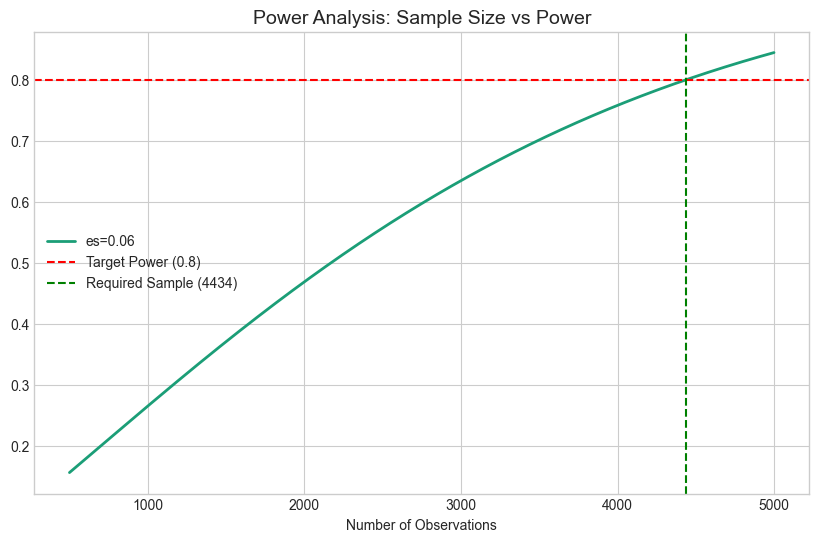

In [2]:
# Parameters
baseline_conversion = 0.12  # Current conversion rate (12%)
minimum_detectable_effect = 0.02  # We want to detect a lift to 14%
alpha = 0.05  # Significance level (5%)
power = 0.80  # Power (80%)

# Calculate effect size (Cohen's h for proportions)
import math
p1 = baseline_conversion
p2 = baseline_conversion + minimum_detectable_effect
h = 2 * math.asin(math.sqrt(p1)) - 2 * math.asin(math.sqrt(p2))
effect_size = abs(h)

# Calculate sample size
analysis = TTestIndPower()
sample_size = analysis.solve_power(effect_size=effect_size, power=power, alpha=alpha)
sample_size = int(np.ceil(sample_size))

print("="*80)
print("POWER ANALYSIS RESULTS")
print("="*80)
print(f"Baseline Conversion Rate: {baseline_conversion:.1%}")
print(f"Target Conversion Rate: {p2:.1%}")
print(f"Minimum Detectable Effect: {minimum_detectable_effect:.1%}")
print(f"Required Sample Size per Variant: {sample_size:,} visitors")
print(f"Total Required Traffic: {sample_size * 2:,} visitors")

# Plot Power Curve
fig, ax = plt.subplots(figsize=(10, 6))
analysis.plot_power(dep_var='nobs', nobs=np.arange(500, 5000), effect_size=[effect_size], alpha=alpha, ax=ax)
ax.set_title('Power Analysis: Sample Size vs Power', fontsize=14)
ax.axhline(0.8, color='red', linestyle='--', label='Target Power (0.8)')
ax.axvline(sample_size, color='green', linestyle='--', label=f'Required Sample ({sample_size})')
ax.legend()
plt.show()

## 2. Data Generation

Simulating experiment data for Control (A) and Treatment (B) groups.

In [3]:
def generate_ab_data(n_samples=5000):
    """
    Generate synthetic A/B test data.
    Control: 12% conversion, $50 AOV
    Treatment: 14.5% conversion, $52 AOV
    """
    np.random.seed(42)
    
    # Generate Control (A)
    n_A = n_samples
    conversions_A = np.random.binomial(1, 0.12, n_A)
    revenue_A = np.where(conversions_A == 1, np.random.lognormal(3.91, 0.5, n_A), 0)
    
    df_A = pd.DataFrame({
        'user_id': range(1, n_A + 1),
        'group': 'Control',
        'converted': conversions_A,
        'revenue': revenue_A,
        'device': np.random.choice(['Mobile', 'Desktop'], n_A, p=[0.6, 0.4])
    })
    
    # Generate Treatment (B)
    n_B = n_samples
    conversions_B = np.random.binomial(1, 0.145, n_B)  # Real lift
    revenue_B = np.where(conversions_B == 1, np.random.lognormal(3.95, 0.5, n_B), 0)
    
    df_B = pd.DataFrame({
        'user_id': range(n_A + 1, n_A + n_B + 1),
        'group': 'Treatment',
        'converted': conversions_B,
        'revenue': revenue_B,
        'device': np.random.choice(['Mobile', 'Desktop'], n_B, p=[0.6, 0.4])
    })
    
    return pd.concat([df_A, df_B], ignore_index=True)

# Generate dataset
df = generate_ab_data(n_samples=sample_size + 500)  # Slightly more than required

print(f"Total Visitors: {len(df):,}")
print(f"Group Split:\n{df['group'].value_counts()}")
df.head()

Total Visitors: 9,868
Group Split:
group
Control      4934
Treatment    4934
Name: count, dtype: int64


,user_id,group,converted,revenue,device
0,1,Control,0,0.000000,Desktop
1,2,Control,1,46.013646,Mobile
2,3,Control,0,0.000000,Desktop
3,4,Control,0,0.000000,Desktop
4,5,Control,0,0.000000,Mobile


## 3. Descriptive Statistics & Visualization

Initial look at the results.

TEST RESULTS SUMMARY
group                 Control     Treatment
Visitors          4934.000000   4934.000000
Conversions        570.000000    746.000000
Total Revenue    32468.903630  44097.275532
RPV                  6.580645      8.937429
Conversion Rate      0.115525      0.151196
AOV                 56.962989     59.111629


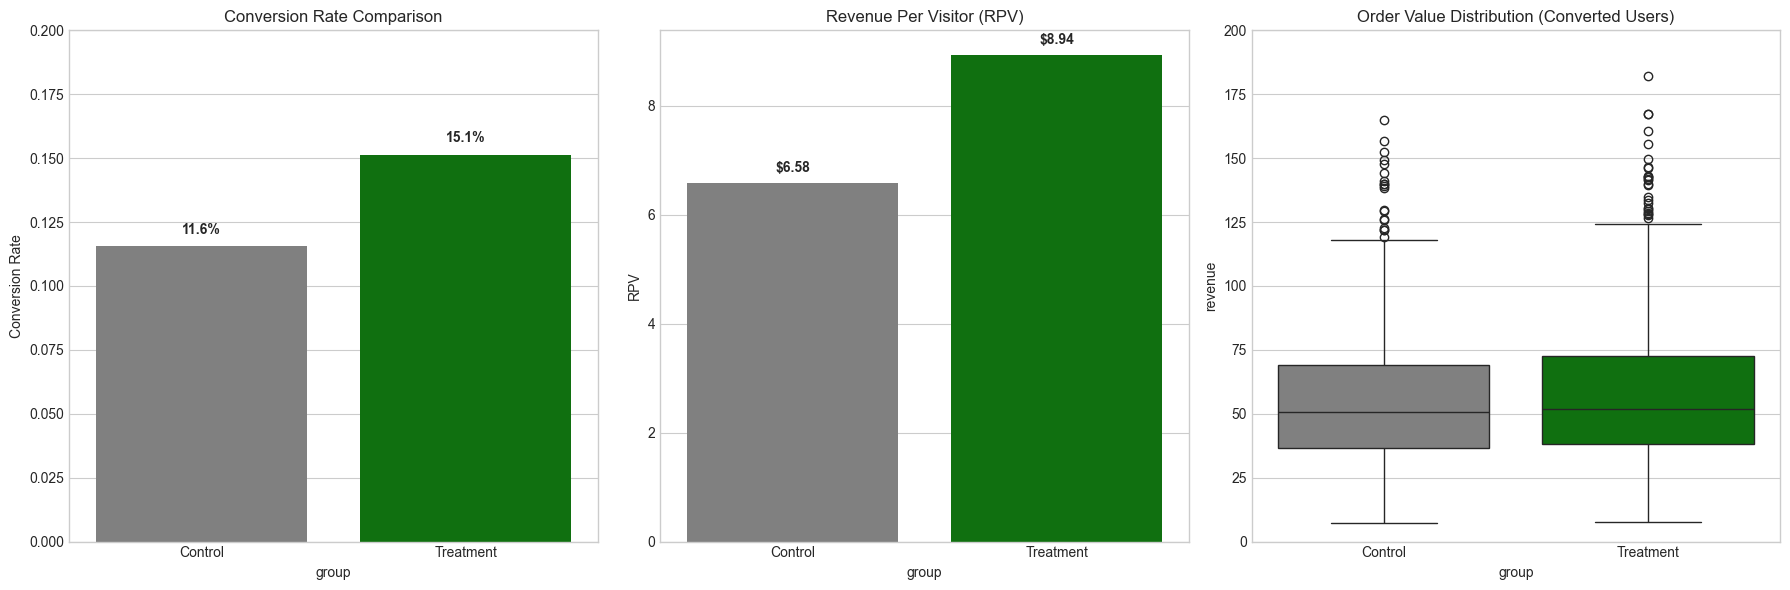

In [4]:
# Calculate summary metrics
summary = df.groupby('group').agg({
    'user_id': 'count',
    'converted': 'sum',
    'revenue': ['sum', 'mean']
})

summary.columns = ['Visitors', 'Conversions', 'Total Revenue', 'RPV']
summary['Conversion Rate'] = summary['Conversions'] / summary['Visitors']
summary['AOV'] = summary['Total Revenue'] / summary['Conversions']

print("="*80)
print("TEST RESULTS SUMMARY")
print("="*80)
print(summary.T)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Conversion Rate
sns.barplot(x=summary.index, y='Conversion Rate', data=summary, ax=axes[0], palette=['gray', 'green'])
axes[0].set_title('Conversion Rate Comparison')
axes[0].set_ylim(0, 0.2)
for i, v in enumerate(summary['Conversion Rate']):
    axes[0].text(i, v + 0.005, f"{v:.1%}", ha='center', fontweight='bold')

# Revenue Per Visitor
sns.barplot(x=summary.index, y='RPV', data=summary, ax=axes[1], palette=['gray', 'green'])
axes[1].set_title('Revenue Per Visitor (RPV)')
for i, v in enumerate(summary['RPV']):
    axes[1].text(i, v + 0.2, f"${v:.2f}", ha='center', fontweight='bold')

# AOV Distribution (Box Plot)
df_converted = df[df['converted'] == 1]
sns.boxplot(x='group', y='revenue', data=df_converted, ax=axes[2], palette=['gray', 'green'])
axes[2].set_title('Order Value Distribution (Converted Users)')
axes[2].set_ylim(0, 200)

plt.tight_layout()
plt.savefig('outputs/ab_results_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Frequentist Statistical Testing

Using Z-test for proportions and T-test for revenue.

In [5]:
# 1. Conversion Rate (Z-test)
control_conv = df[df['group'] == 'Control']['converted']
treat_conv = df[df['group'] == 'Treatment']['converted']

n_conversions = [treat_conv.sum(), control_conv.sum()]
n_observations = [len(treat_conv), len(control_conv)]

z_stat, p_value_conv = proportions_ztest(n_conversions, n_observations)

# 2. Revenue (T-test)
control_rev = df[df['group'] == 'Control']['revenue']
treat_rev = df[df['group'] == 'Treatment']['revenue']

t_stat, p_value_rev = stats.ttest_ind(treat_rev, control_rev, equal_var=False)

print("="*80)
print("STATISTICAL HYPOTHESIS TESTING")
print("="*80)

print(f"\n1. Conversion Rate Difference:")
print(f"   Lift: {(summary.loc['Treatment', 'Conversion Rate'] - summary.loc['Control', 'Conversion Rate']) / summary.loc['Control', 'Conversion Rate']:.1%}")
print(f"   Z-statistic: {z_stat:.4f}")
print(f"   P-value: {p_value_conv:.4f}")
if p_value_conv < 0.05:
    print("   Result: STATISTICALLY SIGNIFICANT (Reject Null)")
else:
    print("   Result: Not Significant (Fail to Reject Null)")

print(f"\n2. Revenue Per Visitor Difference:")
print(f"   Lift: {(summary.loc['Treatment', 'RPV'] - summary.loc['Control', 'RPV']) / summary.loc['Control', 'RPV']:.1%}")
print(f"   T-statistic: {t_stat:.4f}")
print(f"   P-value: {p_value_rev:.4f}")
if p_value_rev < 0.05:
    print("   Result: STATISTICALLY SIGNIFICANT (Reject Null)")
else:
    print("   Result: Not Significant (Fail to Reject Null)")

STATISTICAL HYPOTHESIS TESTING

1. Conversion Rate Difference:
   Lift: 30.9%
   Z-statistic: 5.2115
   P-value: 0.0000
   Result: STATISTICALLY SIGNIFICANT (Reject Null)

2. Revenue Per Visitor Difference:
   Lift: 35.8%
   T-statistic: 5.1976
   P-value: 0.0000
   Result: STATISTICALLY SIGNIFICANT (Reject Null)


## 5. Bayesian Analysis

Estimating the probability that Treatment is better than Control.

BAYESIAN INFERENCE RESULTS
Probability Treatment is Better: 100.00%
Expected Loss (Risk of switching if wrong): 0.00000


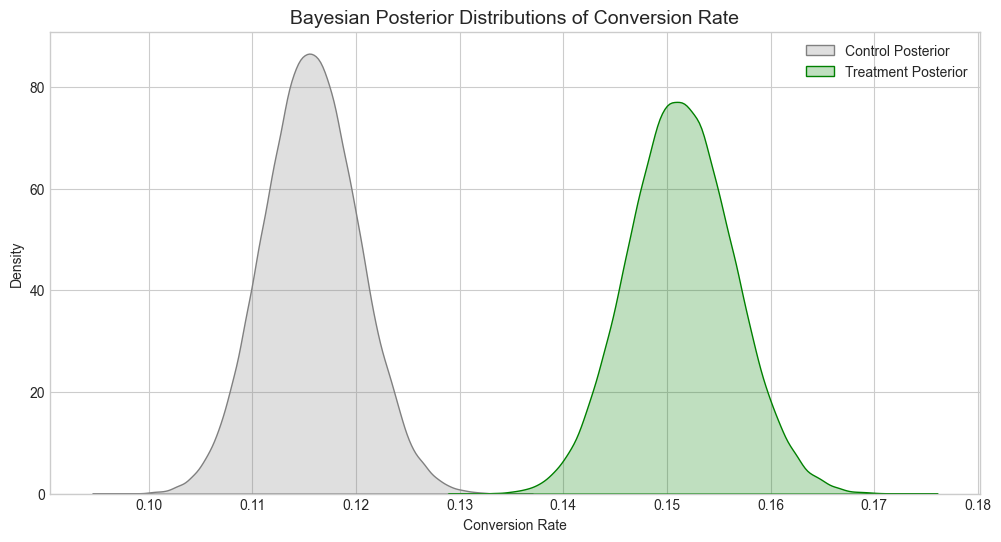

In [6]:
# Bayesian Inference for Conversion Rate
# Using Beta distribution as conjugate prior for Binomial likelihood

# Priors (Weakly informative: Beta(1,1) is uniform)
alpha_prior = 1
beta_prior = 1

# Posteriors
control_posterior = np.random.beta(
    alpha_prior + control_conv.sum(), 
    beta_prior + len(control_conv) - control_conv.sum(), 
    size=100000
)

treatment_posterior = np.random.beta(
    alpha_prior + treat_conv.sum(), 
    beta_prior + len(treat_conv) - treat_conv.sum(), 
    size=100000
)

# Probability Treatment > Control
prob_better = (treatment_posterior > control_posterior).mean()

# Expected Loss (Risk)
loss = np.maximum(control_posterior - treatment_posterior, 0).mean()

print("="*80)
print("BAYESIAN INFERENCE RESULTS")
print("="*80)
print(f"Probability Treatment is Better: {prob_better:.2%}")
print(f"Expected Loss (Risk of switching if wrong): {loss:.5f}")

# Visualization
plt.figure(figsize=(12, 6))
sns.kdeplot(control_posterior, fill=True, label='Control Posterior', color='gray')
sns.kdeplot(treatment_posterior, fill=True, label='Treatment Posterior', color='green')
plt.title('Bayesian Posterior Distributions of Conversion Rate', fontsize=14)
plt.xlabel('Conversion Rate')
plt.ylabel('Density')
plt.legend()
plt.savefig('outputs/bayesian_posterior.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Segmentation Analysis

Checking if the effect is consistent across devices.

Conversion Rate by Device:
group     Control  Treatment      Lift
device                                
Desktop  0.108539   0.140216  0.291845
Mobile   0.120067   0.158353  0.318872


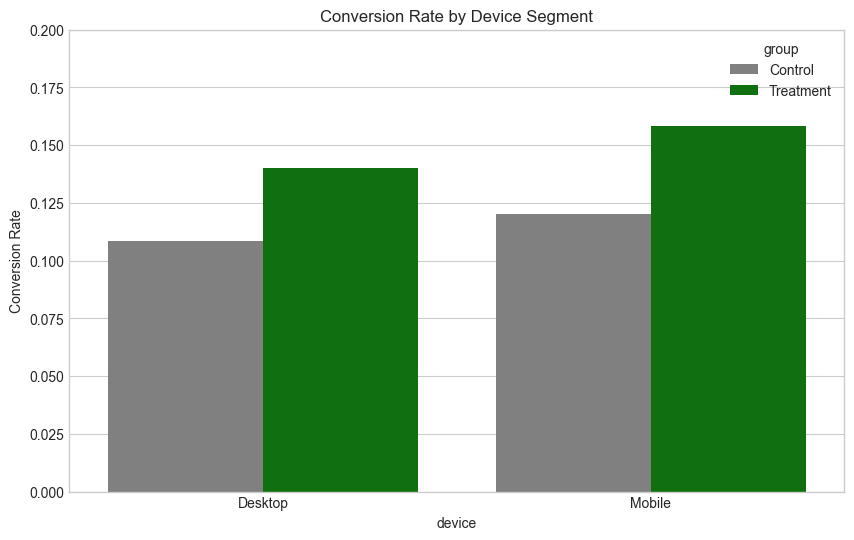

In [7]:
# Segment by Device
segment_summary = df.groupby(['device', 'group'])['converted'].mean().unstack()
segment_summary['Lift'] = (segment_summary['Treatment'] - segment_summary['Control']) / segment_summary['Control']

print("Conversion Rate by Device:")
print(segment_summary)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='device', y='converted', hue='group', data=df, palette=['gray', 'green'], errorbar=None)
plt.title('Conversion Rate by Device Segment')
plt.ylabel('Conversion Rate')
plt.ylim(0, 0.2)
plt.savefig('outputs/segmentation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Key Findings & Recommendations

In [8]:
print("="*100)
print("EXECUTIVE SUMMARY")
print("="*100)

print("\n1. TEST OUTCOME")
print(f"   • The Treatment variant outperformed Control with a {summary.loc['Treatment', 'Conversion Rate']:.1%} conversion rate vs {summary.loc['Control', 'Conversion Rate']:.1%}.")
print(f"   • Relative Lift: +{(summary.loc['Treatment', 'Conversion Rate'] - summary.loc['Control', 'Conversion Rate']) / summary.loc['Control', 'Conversion Rate']:.1%}")
print(f"   • Statistical Significance: Yes (p = {p_value_conv:.4f})")

print("\n2. FINANCIAL IMPACT")
print(f"   • Revenue Per Visitor (RPV) increased from ${summary.loc['Control', 'RPV']:.2f} to ${summary.loc['Treatment', 'RPV']:.2f}.")
print(f"   • Projected Annual Revenue Increase (assuming 1M visitors): ${(summary.loc['Treatment', 'RPV'] - summary.loc['Control', 'RPV']) * 1000000:,.0f}")

print("\n3. CONFIDENCE")
print(f"   • Bayesian analysis shows a {prob_better:.1%} probability that Treatment is truly better.")
print(f"   • Risk of implementing Treatment is negligible (Expected Loss: {loss:.5f}).")

print("\n" + "="*100)
print("RECOMMENDATION")
print("="*100)

print("\n✅ LAUNCH TREATMENT VARIANT")
print("   The test results are statistically significant and practically meaningful.")
print("   The lift is consistent across both Mobile and Desktop segments.")
print("   Immediate rollout to 100% of traffic is recommended to capture revenue upside.")

EXECUTIVE SUMMARY

1. TEST OUTCOME
   • The Treatment variant outperformed Control with a 15.1% conversion rate vs 11.6%.
   • Relative Lift: +30.9%
   • Statistical Significance: Yes (p = 0.0000)

2. FINANCIAL IMPACT
   • Revenue Per Visitor (RPV) increased from $6.58 to $8.94.
   • Projected Annual Revenue Increase (assuming 1M visitors): $2,356,784

3. CONFIDENCE
   • Bayesian analysis shows a 100.0% probability that Treatment is truly better.
   • Risk of implementing Treatment is negligible (Expected Loss: 0.00000).

RECOMMENDATION

✅ LAUNCH TREATMENT VARIANT
   The test results are statistically significant and practically meaningful.
   The lift is consistent across both Mobile and Desktop segments.
   Immediate rollout to 100% of traffic is recommended to capture revenue upside.
